# Comparison of Logistic Regression and K-Nearest Neighbors (KNN) Classifiers

## Aim
Implement Logistic Regression and K-Nearest Neighbors (KNN) on the Breast Cancer Wisconsin (Diagnostic) dataset and compare their performances using classification evaluation metrics.

## Dataset Description
The Breast Cancer Wisconsin (Diagnostic) dataset contains 569 instances and 32 attributes. The target variable is diagnosis ('M' for Malignant and 'B' for Benign). The dataset does not contain headers.


## Section 1: Import Libraries
Import required libraries for data handling, plotting, model building, and evaluation metrics.


In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix

import os
import time
import warnings
warnings.filterwarnings('ignore')


## Section 2: Load Dataset
Load the dataset from CSV file, assign column names, and inspect its basic properties.


In [2]:
# Load dataset
column_names = [
    'id', 'diagnosis',
    'radius_mean', 'texture_mean', 'perimeter_mean', 'area_mean', 'smoothness_mean',
    'compactness_mean', 'concavity_mean', 'concave_points_mean', 'symmetry_mean', 'fractal_dimension_mean',
    'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se',
    'compactness_se', 'concavity_se', 'concave_points_se', 'symmetry_se', 'fractal_dimension_se',
    'radius_worst', 'texture_worst', 'perimeter_worst', 'area_worst', 'smoothness_worst',
    'compactness_worst', 'concavity_worst', 'concave_points_worst', 'symmetry_worst', 'fractal_dimension_worst'
]

df = pd.read_csv('wdbc.csv', header=None, names=column_names)


In [ ]:
# Display first five rows
print(df.head())


         id diagnosis  radius_mean  texture_mean  perimeter_mean  area_mean  \
0    842302         M        17.99         10.38          122.80     1001.0   
1    842517         M        20.57         17.77          132.90     1326.0   
2  84300903         M        19.69         21.25          130.00     1203.0   
3  84348301         M        11.42         20.38           77.58      386.1   
4  84358402         M        20.29         14.34          135.10     1297.0   

   smoothness_mean  compactness_mean  concavity_mean  concave_points_mean  \
0          0.11840           0.27760          0.3001              0.14710   
1          0.08474           0.07864          0.0869              0.07017   
2          0.10960           0.15990          0.1974              0.12790   
3          0.14250           0.28390          0.2414              0.10520   
4          0.10030           0.13280          0.1980              0.10430   

   ...  radius_worst  texture_worst  perimeter_worst  area_wor

In [ ]:
# Display last five rows
print(df.tail())


         id diagnosis  radius_mean  texture_mean  perimeter_mean  area_mean  \
564  926424         M        21.56         22.39          142.00     1479.0   
565  926682         M        20.13         28.25          131.20     1261.0   
566  926954         M        16.60         28.08          108.30      858.1   
567  927241         M        20.60         29.33          140.10     1265.0   
568   92751         B         7.76         24.54           47.92      181.0   

     smoothness_mean  compactness_mean  concavity_mean  concave_points_mean  \
564          0.11100           0.11590         0.24390              0.13890   
565          0.09780           0.10340         0.14400              0.09791   
566          0.08455           0.10230         0.09251              0.05302   
567          0.11780           0.27700         0.35140              0.15200   
568          0.05263           0.04362         0.00000              0.00000   

     ...  radius_worst  texture_worst  perimeter_w

In [ ]:
# Display shape
print(df.shape)


(569, 32)


In [ ]:
# Display column names
print(df.columns)


Index(['id', 'diagnosis', 'radius_mean', 'texture_mean', 'perimeter_mean',
       'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean',
       'concave_points_mean', 'symmetry_mean', 'fractal_dimension_mean',
       'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se',
       'compactness_se', 'concavity_se', 'concave_points_se', 'symmetry_se',
       'fractal_dimension_se', 'radius_worst', 'texture_worst',
       'perimeter_worst', 'area_worst', 'smoothness_worst',
       'compactness_worst', 'concavity_worst', 'concave_points_worst',
       'symmetry_worst', 'fractal_dimension_worst'],
      dtype='object')


In [ ]:
# Display data types
print(df.dtypes)


id                           int64
diagnosis                   object
radius_mean                float64
texture_mean               float64
perimeter_mean             float64
area_mean                  float64
smoothness_mean            float64
compactness_mean           float64
concavity_mean             float64
concave_points_mean        float64
symmetry_mean              float64
fractal_dimension_mean     float64
radius_se                  float64
texture_se                 float64
perimeter_se               float64
area_se                    float64
smoothness_se              float64
compactness_se             float64
concavity_se               float64
concave_points_se          float64
symmetry_se                float64
fractal_dimension_se       float64
radius_worst               float64
texture_worst              float64
perimeter_worst            float64
area_worst                 float64
smoothness_worst           float64
compactness_worst          float64
concavity_worst     

In [ ]:
# Display dataset info
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 32 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave_points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             5

In [ ]:
# Display summary statistics
print(df.describe())


                 id  radius_mean  texture_mean  perimeter_mean    area_mean  \
count  5.690000e+02   569.000000    569.000000      569.000000   569.000000   
mean   3.037183e+07    14.127292     19.289649       91.969033   654.889104   
std    1.250206e+08     3.524049      4.301036       24.298981   351.914129   
min    8.670000e+03     6.981000      9.710000       43.790000   143.500000   
25%    8.692180e+05    11.700000     16.170000       75.170000   420.300000   
50%    9.060240e+05    13.370000     18.840000       86.240000   551.100000   
75%    8.813129e+06    15.780000     21.800000      104.100000   782.700000   
max    9.113205e+08    28.110000     39.280000      188.500000  2501.000000   

       smoothness_mean  compactness_mean  concavity_mean  concave_points_mean  \
count       569.000000        569.000000      569.000000           569.000000   
mean          0.096360          0.104341        0.088799             0.048919   
std           0.014064          0.052813     

In [ ]:
# Check missing values
print(df.isnull().sum())


id                         0
diagnosis                  0
radius_mean                0
texture_mean               0
perimeter_mean             0
area_mean                  0
smoothness_mean            0
compactness_mean           0
concavity_mean             0
concave_points_mean        0
symmetry_mean              0
fractal_dimension_mean     0
radius_se                  0
texture_se                 0
perimeter_se               0
area_se                    0
smoothness_se              0
compactness_se             0
concavity_se               0
concave_points_se          0
symmetry_se                0
fractal_dimension_se       0
radius_worst               0
texture_worst              0
perimeter_worst            0
area_worst                 0
smoothness_worst           0
compactness_worst          0
concavity_worst            0
concave_points_worst       0
symmetry_worst             0
fractal_dimension_worst    0
dtype: int64


In [ ]:
# Check duplicate rows
print(df.duplicated().sum())


0


In [ ]:
# Check unique values
print(df.nunique())


id                         569
diagnosis                    2
radius_mean                456
texture_mean               479
perimeter_mean             522
area_mean                  539
smoothness_mean            474
compactness_mean           537
concavity_mean             537
concave_points_mean        542
symmetry_mean              432
fractal_dimension_mean     499
radius_se                  540
texture_se                 519
perimeter_se               533
area_se                    528
smoothness_se              547
compactness_se             541
concavity_se               533
concave_points_se          507
symmetry_se                498
fractal_dimension_se       545
radius_worst               457
texture_worst              511
perimeter_worst            514
area_worst                 544
smoothness_worst           411
compactness_worst          529
concavity_worst            539
concave_points_worst       492
symmetry_worst             500
fractal_dimension_worst    535
dtype: i

In [ ]:
# Check class distribution
print(df['diagnosis'].value_counts())


diagnosis
B    357
M    212
Name: count, dtype: int64


## Section 3: Exploratory Data Analysis
Visualize the target distribution, feature correlations, feature distributions, boxplots, and pairplot.


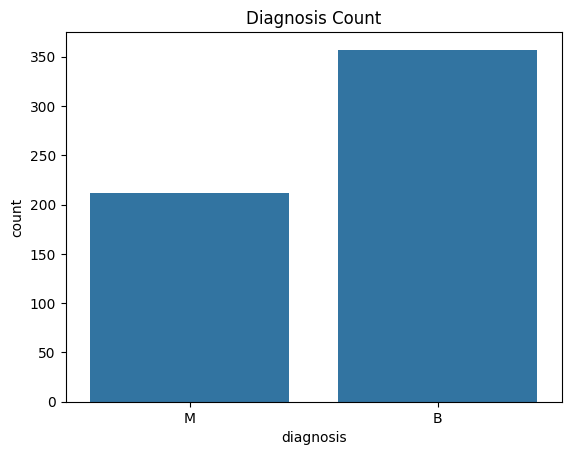

In [ ]:
# Count plot
sns.countplot(x='diagnosis', data=df)
plt.title("Diagnosis Count")
plt.show()


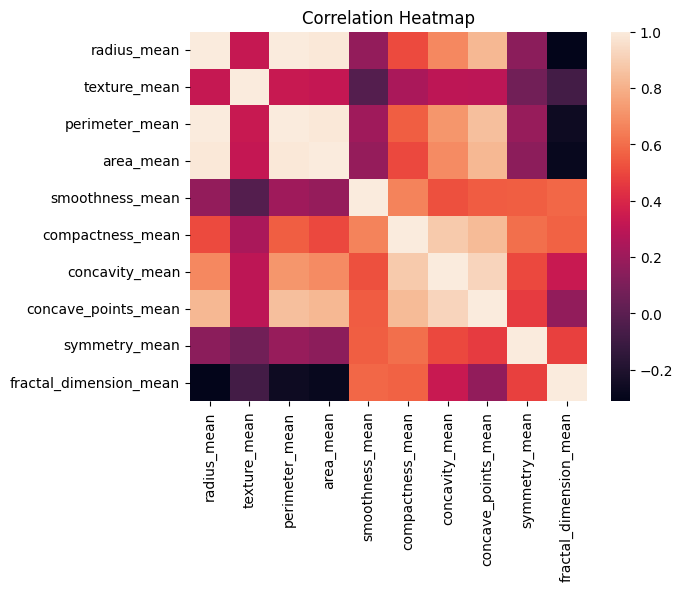

In [ ]:
# Correlation heatmap
mean_cols = [col for col in df.columns if '_mean' in col]
sns.heatmap(df[mean_cols].corr())
plt.title("Correlation Heatmap")
plt.show()


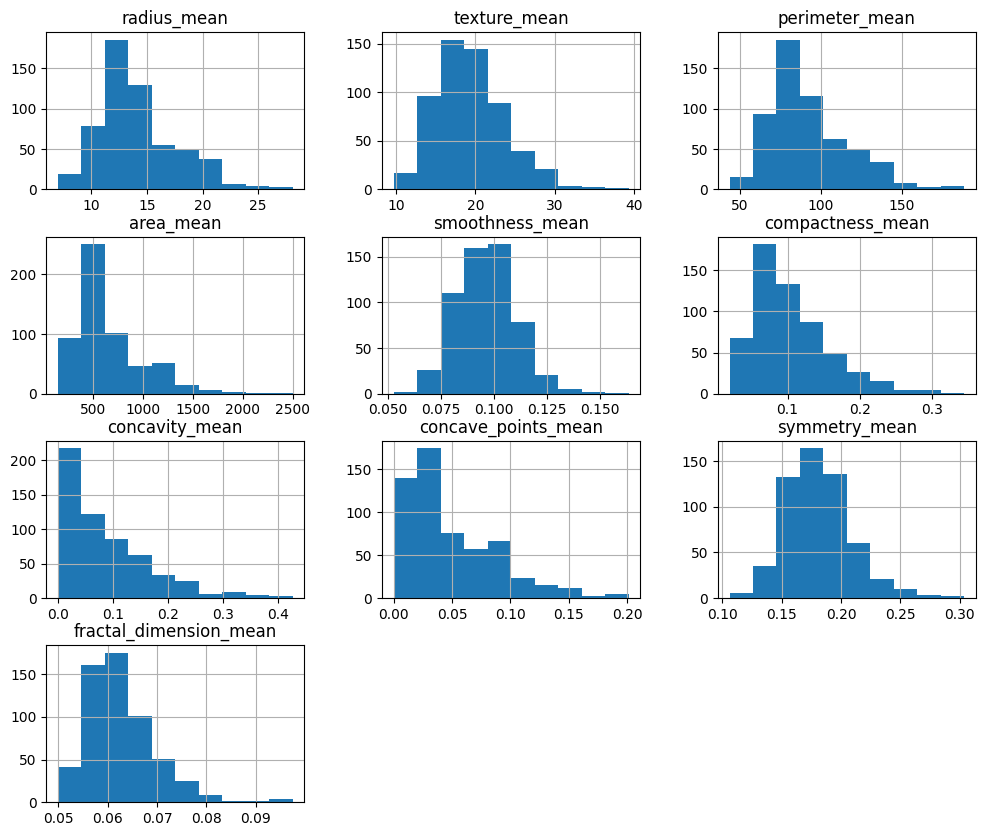

In [ ]:
# Histograms
df[mean_cols].hist(figsize=(12, 10))
plt.show()


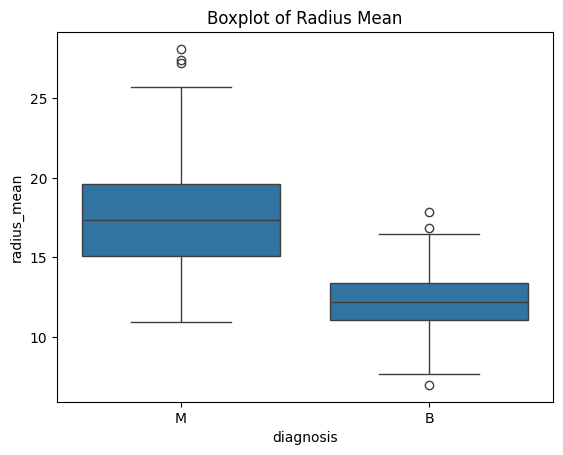

In [ ]:
# Boxplot
sns.boxplot(x='diagnosis', y='radius_mean', data=df)
plt.title("Boxplot of Radius Mean")
plt.show()


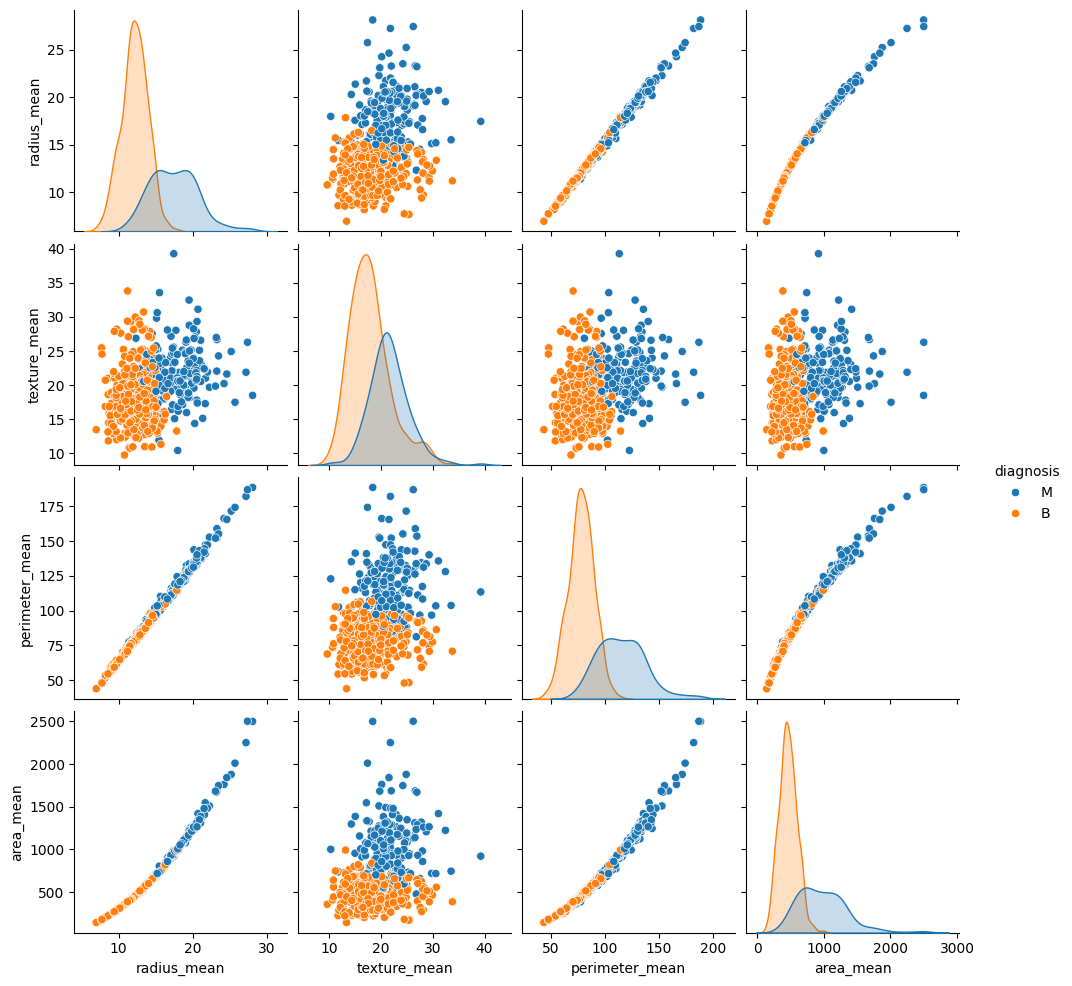

In [ ]:
# Pairplot
sns.pairplot(df[['diagnosis', 'radius_mean', 'texture_mean', 'perimeter_mean', 'area_mean']], hue='diagnosis')
plt.show()


## Section 4: Data Preprocessing
Encode the target column (M to 1, B to 0), drop the ID column, separate features X and target y, and split the data into training and testing sets.


In [ ]:
# Encode diagnosis column
df['diagnosis'] = df['diagnosis'].map({'M': 1, 'B': 0})


In [ ]:
# Drop ID column and create X and y
X = df.drop(columns=['id', 'diagnosis'])
y = df['diagnosis']


In [ ]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)
print(X_train.shape, X_test.shape)


(455, 30) (114, 30)


## Section 5: Feature Scaling
Scale features using StandardScaler to bring all feature values to a similar scale for distance calculation in KNN and gradient optimization in Logistic Regression.


In [ ]:
# Feature scaling using StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


## Section 6: Logistic Regression
Train a Logistic Regression classifier on the scaled training dataset and predict labels for the test set.


In [ ]:
# Train Logistic Regression
lr = LogisticRegression(random_state=42, max_iter=1000)
lr.fit(X_train_scaled, y_train)


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [ ]:
# Predict Logistic Regression
y_pred_lr = lr.predict(X_test_scaled)
print(y_pred_lr[:10])


[0 1 0 1 1 0 1 0 0 0]


## Section 7: K-Nearest Neighbors
Train initial KNN with K=5, evaluate testing accuracy for K values from 1 to 20, plot accuracy versus K, find the best K, and retrain the model.


In [ ]:
# Train initial KNN (K=5)
knn_init = KNeighborsClassifier(n_neighbors=5)
knn_init.fit(X_train_scaled, y_train)
print(accuracy_score(y_test, knn_init.predict(X_test_scaled)))


0.956140350877193


In [ ]:
# Find best K from 1 to 20
k_values = list(range(1, 21))
k_accuracies = []

for k in k_values:
    knn_model = KNeighborsClassifier(n_neighbors=k)
    knn_model.fit(X_train_scaled, y_train)
    acc = accuracy_score(y_test, knn_model.predict(X_test_scaled))
    k_accuracies.append(acc)

best_k = k_values[np.argmax(k_accuracies)]
print("Best K:", best_k)


Best K: 5


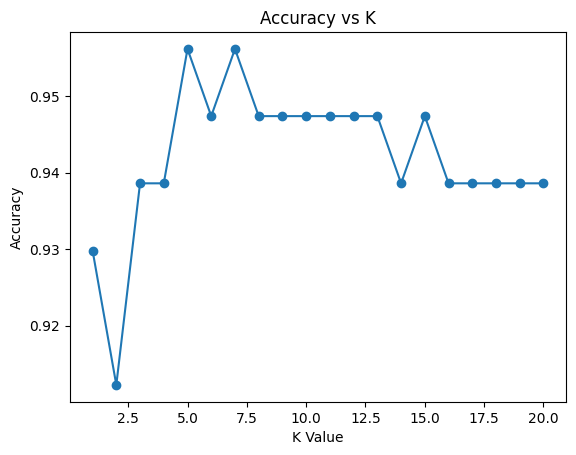

In [ ]:
# Plot Accuracy vs K
plt.plot(k_values, k_accuracies, marker='o')
plt.xlabel("K Value")
plt.ylabel("Accuracy")
plt.title("Accuracy vs K")
plt.show()


In [ ]:
# Train final KNN with best K and predict
knn = KNeighborsClassifier(n_neighbors=best_k)
knn.fit(X_train_scaled, y_train)
y_pred_knn = knn.predict(X_test_scaled)
print(y_pred_knn[:10])


[0 1 0 0 0 0 1 0 0 0]


## Section 8: Model Evaluation
Evaluate Logistic Regression and KNN using accuracy, precision, recall, F1 score, classification report, and confusion matrices.


In [ ]:
# Logistic Regression metrics
print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_lr))
print("Precision:", precision_score(y_test, y_pred_lr))
print("Recall:", recall_score(y_test, y_pred_lr))
print("F1 Score:", f1_score(y_test, y_pred_lr))
print("Classification Report:", classification_report(y_test, y_pred_lr))


Logistic Regression Accuracy: 0.9649122807017544
Precision: 0.975
Recall: 0.9285714285714286
F1 Score: 0.9512195121951219
Classification Report:               precision    recall  f1-score   support

           0       0.96      0.99      0.97        72
           1       0.97      0.93      0.95        42

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114



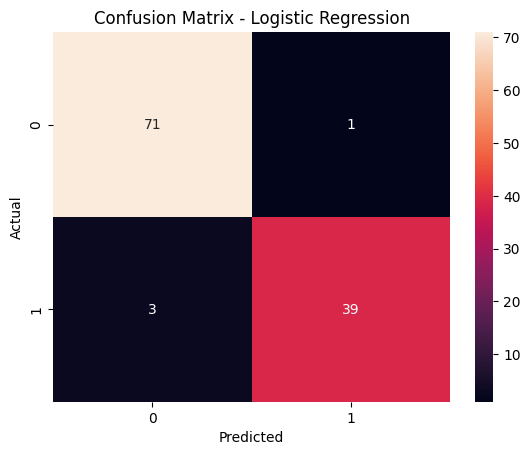

In [ ]:
# Logistic Regression confusion matrix
cm_lr = confusion_matrix(y_test, y_pred_lr)
sns.heatmap(cm_lr, annot=True)
plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


In [ ]:
# KNN metrics
print("KNN Accuracy:", accuracy_score(y_test, y_pred_knn))
print("Precision:", precision_score(y_test, y_pred_knn))
print("Recall:", recall_score(y_test, y_pred_knn))
print("F1 Score:", f1_score(y_test, y_pred_knn))
print("Classification Report:", classification_report(y_test, y_pred_knn))


KNN Accuracy: 0.956140350877193
Precision: 0.9743589743589743
Recall: 0.9047619047619048
F1 Score: 0.9382716049382716
Classification Report:               precision    recall  f1-score   support

           0       0.95      0.99      0.97        72
           1       0.97      0.90      0.94        42

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



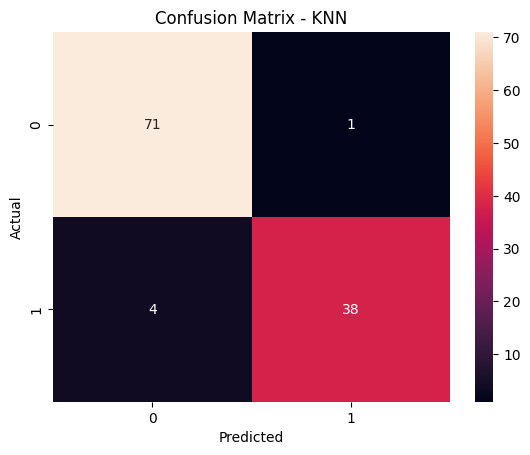

In [ ]:
# KNN confusion matrix
cm_knn = confusion_matrix(y_test, y_pred_knn)
sns.heatmap(cm_knn, annot=True)
plt.title("Confusion Matrix - KNN")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


## Section 9: Comparison Table
Create a Pandas DataFrame comparing evaluation metrics of Logistic Regression and KNN.


In [ ]:
# Comparison table
comparison_df = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1 Score'],
    'Logistic Regression': [
        accuracy_score(y_test, y_pred_lr),
        precision_score(y_test, y_pred_lr),
        recall_score(y_test, y_pred_lr),
        f1_score(y_test, y_pred_lr)
    ],
    'KNN': [
        accuracy_score(y_test, y_pred_knn),
        precision_score(y_test, y_pred_knn),
        recall_score(y_test, y_pred_knn),
        f1_score(y_test, y_pred_knn)
    ]
})

print(comparison_df)


      Metric  Logistic Regression       KNN
0   Accuracy             0.964912  0.956140
1  Precision             0.975000  0.974359
2     Recall             0.928571  0.904762
3   F1 Score             0.951220  0.938272


## Section 10: Interpretation
Compare model performances and draw conclusions based on evaluation metrics.


In [ ]:
# Conclusion
print("Conclusion:")
if accuracy_score(y_test, y_pred_lr) >= accuracy_score(y_test, y_pred_knn):
    print("Logistic Regression performed better than KNN on this dataset.")
else:
    print("KNN performed better than Logistic Regression on this dataset.")


Conclusion:
Logistic Regression performed better than KNN on this dataset.


## Section 11: Save Results
Save all generated plots in the outputs directory.


In [ ]:
# Save results to outputs folder
os.makedirs('outputs', exist_ok=True)

# Count plot
plt.figure()
sns.countplot(x='diagnosis', data=df)
plt.title("Diagnosis Count")
plt.savefig('outputs/count_plot.png')
plt.close()

# Heatmap
plt.figure()
sns.heatmap(df[mean_cols].corr())
plt.title("Correlation Heatmap")
plt.savefig('outputs/correlation_heatmap.png')
plt.close()

# Histograms
df[mean_cols].hist(figsize=(12, 10))
plt.savefig('outputs/histograms.png')
plt.close()

# Boxplot
plt.figure()
sns.boxplot(x='diagnosis', y='radius_mean', data=df)
plt.title("Boxplot of Radius Mean")
plt.savefig('outputs/boxplots.png')
plt.close()

# Pairplot
g = sns.pairplot(df[['diagnosis', 'radius_mean', 'texture_mean', 'perimeter_mean', 'area_mean']], hue='diagnosis')
g.savefig('outputs/pairplot.png')
plt.close()

# Accuracy vs K
plt.figure()
plt.plot(k_values, k_accuracies, marker='o')
plt.xlabel("K Value")
plt.ylabel("Accuracy")
plt.title("Accuracy vs K")
plt.savefig('outputs/accuracy_vs_k.png')
plt.close()

# Confusion matrices
plt.figure()
sns.heatmap(cm_lr, annot=True)
plt.title("Confusion Matrix - Logistic Regression")
plt.savefig('outputs/confusion_matrix_logistic_regression.png')
plt.close()

plt.figure()
sns.heatmap(cm_knn, annot=True)
plt.title("Confusion Matrix - KNN")
plt.savefig('outputs/confusion_matrix_knn.png')
plt.close()

print("Outputs saved successfully.")


Outputs saved successfully.


## Section 12: Final Output
Display final completion confirmation, comparison table, best model, best accuracy, and execution time.


In [ ]:
# Final output
start_time = time.time()
print("Lab Completed Successfully")
print("Final Comparison Table:")
print(comparison_df)
print("Best Model:", "Logistic Regression" if accuracy_score(y_test, y_pred_lr) >= accuracy_score(y_test, y_pred_knn) else "KNN")
print("Best Accuracy:", max(accuracy_score(y_test, y_pred_lr), accuracy_score(y_test, y_pred_knn)))


Lab Completed Successfully
Final Comparison Table:
      Metric  Logistic Regression       KNN
0   Accuracy             0.964912  0.956140
1  Precision             0.975000  0.974359
2     Recall             0.928571  0.904762
3   F1 Score             0.951220  0.938272
Best Model: Logistic Regression
Best Accuracy: 0.9649122807017544
